# Filename......: MT_OlisBahari_ITAI1371.ipynb
# Language......: Python
# Tools.........: Colab Research Google
# Course........: ITAI 1371 Introduction to Machine Learning
# Semester......: Summer 2026
# Class Type....: Online
# Instructor....: Sitaram Ayyagari
# Student.......: Olis Bahari
# Project.......: Midterm Project Data Storytelling
# Dataset.......: Titanic Survival Dataset
# Version.......: V2.0
# Purpose.......: Complete Machine Learning workflow load data, EDA, data preparation,
#                 modeling, and evaluation.

In [15]:
# Global Definition & Interfaing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [16]:
# <<< load dataset >>>
def load_dataset():
    sns.set_style("whitegrid")

    dataset_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

    try:
        df = pd.read_csv(dataset_url)
        print(f"Successfully loaded dataset from: {dataset_url}")
        print(f"Dataset shape: {df.shape}")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

    print("\n--- First 5 Rows ---")
    print(df.head())

    print("\n--- Data Info ---")
    df.info()

    print("\n--- Basic Statistics ---")
    print(df.describe())

    return df


In [17]:
# <<< exploratory data analysis EDA >>>
def exploratory_data_analysis(df):

    # Visualization of Survival

    # By Gender
    plt.figure(figsize=(8, 5))
    sns.countplot(x="Sex", hue="Survived", data=df)
    plt.title("Survival by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Number of Passengers")
    plt.legend(title="Survived", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

    # By Passenger Class
    plt.figure(figsize=(8, 5))
    sns.countplot(x="Pclass", hue="Survived", data=df)
    plt.title("Survival by Passenger Class")
    plt.xlabel("Passenger Class")
    plt.ylabel("Number of Passengers")
    plt.legend(title="Survived", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

    # By Age Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x="Age", hue="Survived", kde=True, bins=30)
    plt.title("Age Distribution by Survival")
    plt.xlabel("Age")
    plt.ylabel("Number of Passengers")
    plt.tight_layout()
    plt.show()

    return(df)


In [18]:
# <<< Data Preparation and Feature Engineering >>>
def data_preparation(df):
    print("\n--- Missing Values Before Cleaning ---")
    print(df.isnull().sum())

    # Fill missing Age values with the median
    # Median is useful because age can have outliers.
    df["Age"] = df["Age"].fillna(df["Age"].median())

    # Fill missing Embarked values with the mode
    # Mode is useful for categorical data.
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    print("\n--- Missing Values After Cleaning ---")
    print(df.isnull().sum())

    # Encode Sex:
    # male = 0,
    # female = 1
    df["Sex_encoded"] = df["Sex"].map({"male": 0, "female": 1})

    # Encode embarked using dummy variables
    # drop_first=True avoids duplicate information between columns.
    df = pd.get_dummies(df, columns=["Embarked"], drop_first=True, dtype=int)

    print("\n--- Data After Encoding ---")
    print(df.head())

    return(df)


In [19]:
# <<< Modeling with Logistic Regression >>>
def modeling(df):
    # Select numeric features for the model
    features = [
        "Pclass",
        "Sex_encoded",
        "Age",
        "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S"
    ]

    X = df[features]
    y = df["Survived"]

    # Split the data into 80% training and 20% testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    print("\n<<< Train/Test Split >>>")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")
    print(f"Features used: {features}")

    # Create and train Logistic Regression model
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train, y_train)

    # Make predictions
    y_pred_log_reg = log_reg.predict(X_test)

    # Calculate accuracy
    acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

    print("\n <<< Logistic Regression Accuracy >>>")
    print(f"Accuracy: {acc_log_reg:.2%}")

    return y_test, y_pred_log_reg


In [20]:
# <<< evaluation routine >>>
def evaluation(y_test, y_pred_log_reg):

    print("\n <<< Classification Report >>>")
    print(classification_report(y_test, y_pred_log_reg))

    print("\n<<< Confusion Matrix >>>")

    cm = confusion_matrix(y_test, y_pred_log_reg)
    print(cm)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Logistic Regression")
    plt.tight_layout()
    plt.show()


Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2 

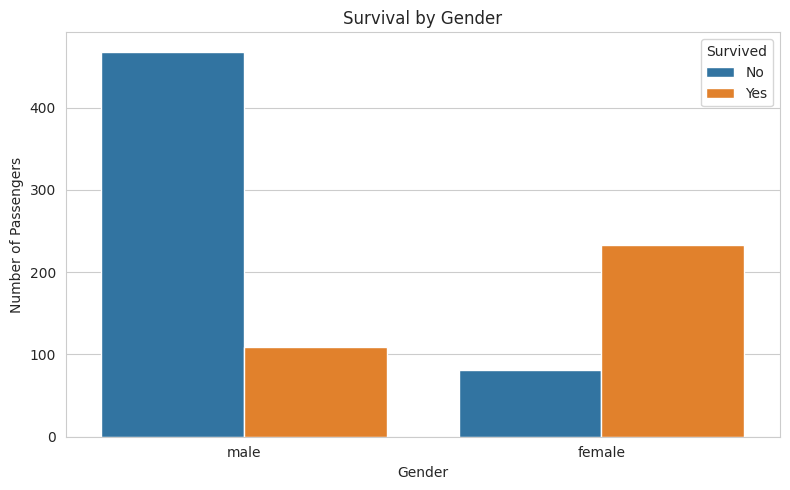

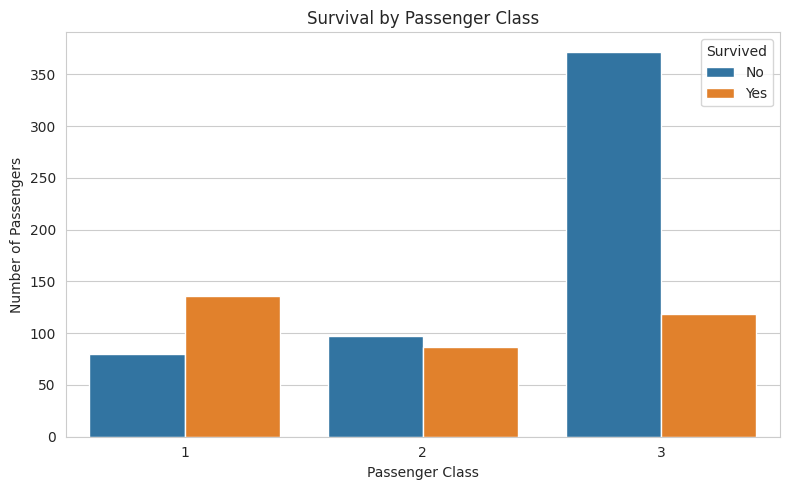

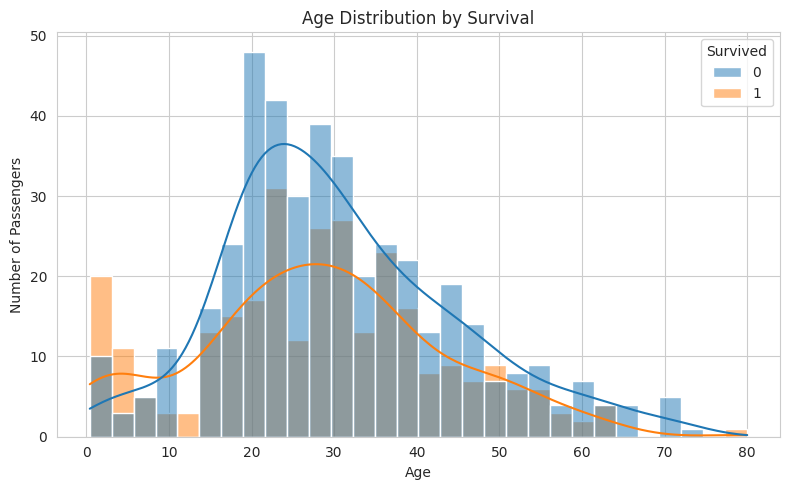


--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values After Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

--- Data After Encoding ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence

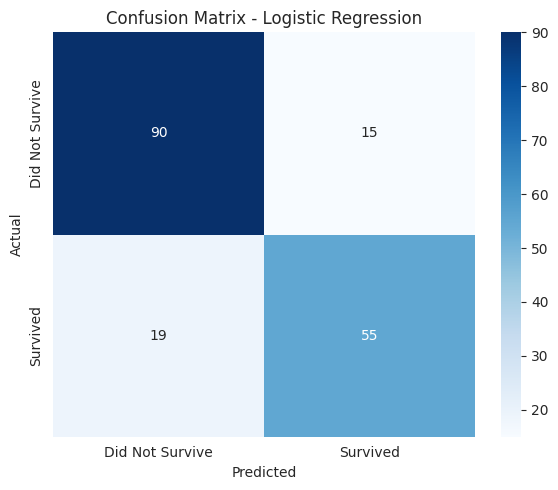

In [21]:
# <<< Main Code >>>

df = load_dataset()

if df is not None:
    exploratory_data_analysis(df)
    df = data_preparation(df)
    y_test, y_pred_log_reg = modeling(df)
    evaluation(y_test, y_pred_log_reg)
else:
    print("Program stopped because dataset could not be loaded.")


Midterm Ptoject Conclusion

The primary objective of this project was to develop a machine learning model to predict Titanic passenger survival using variables such as passenger class, gender, age, family size, fare, and embarkation point.

I implemented the complete machine learning workflow, including data loading, exploratory analysis, data cleaning and preparation, model construction using Logistic Regression, and evaluation of model performance.

This project demonstrated that machine learning can make meaningful survival predictions, with gender, class, fare, and age emerging as the key factors.

During data exploration, I observed that gender had the strongest influence on survival outcomes.

Female passengers had a substantially higher survival rate than male passengers. Passenger class was also influential, with first-class passengers surviving more frequently than those in second or third class.

Age had a moderate effect on survival, though its impact was less pronounced than that of gender or class. The most influential features for predicting survival were gender, class, fare, and age.

The Logistic Regression model performed effectively at predicting survival, indicating that it identified important patterns in the dataset.

However, accuracy alone does not provide a comprehensive assessment. The classification report indicated that precision and recall varied across groups, suggesting the model occasionally misclassified outcomes.

Overall, the model demonstrated satisfactory performance, though it is essential to consider both its strengths and limitations. Given additional time, I would pursue further feature engineering and compare Logistic Regression with alternative models such as Decision Trees or Random Forests to potentially improve predictive accuracy.

